# Self-consistent Schrödinger-Poisson: exciton binding in the InSb/InAs dot

Adds back the Poisson self-consistency `aestimo` itself does in 1D, to the single-band 3D dot
solver -- letting the confined electron and hole attract each other electrostatically. This is
a direct fix for something flagged as a real gap all the way back in the first 3D sketch: the
"naive transition energy" (just `E_e - E_h` from two independent solves) ignores electron-hole
Coulomb attraction, which matters more here than in a type-I system because the carriers are
spatially separated (electron mostly in the InAs barriers, hole in the InSb dot).

Multiband k.p is dropped for now (it hit a severe sparse-factorization scaling wall for the
fully-coupled 6-band problem); this returns to the well-validated single-band solver.

## Method

Each iteration: solve the electron and hole Schrödinger equations in the current total
potential (confinement + the other carrier's electrostatic field), get new densities, solve
Poisson for updated fields, damp and repeat.

Two things worth knowing about the implementation (both found by testing against known
physics before trusting a result, same discipline as everywhere else in this project):

1. **No self-interaction**: sourcing the potential from the *combined* density $p(r)-n(r)$
   would have each particle feel a spurious contribution from its own charge. Instead, two
   separate Poisson solves are used per iteration -- $\phi_n$ (sourced by the electron alone,
   felt by the hole) and $\phi_p$ (sourced by the hole alone, felt by the electron).
2. **Double counting**: naively taking `E_e - E_h` from the self-consistent eigenvalues is
   *not* the transition energy -- each eigenvalue already includes the full mutual interaction
   once, so summing them counts it twice (the standard Hartree double-counting problem). First
   attempt at this gave the transition energy *increasing* very slightly under an attractive
   interaction -- the wrong sign entirely -- purely from this bug. The fix subtracts the
   interaction energy once: `E_e - E_h + E_int`, where
   `E_int = integral of p(r)*phi_n(r) dV` (confirmed to agree in magnitude with the equivalent
   calculation from the electron's side, `-integral of n(r)*phi_p(r) dV` -- they differ in sign
   only because $\phi_n$ and $\phi_p$ are themselves oppositely signed potentials, not because
   of an error).

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qdsolver_core as qd
from schrodinger_poisson import self_consistent_exciton

## Geometry and fields: InSb dot in InAs (type-II)

In [2]:
matrix_mat, dot_mat = qd.MATERIALS['InAs'], qd.MATERIALS['InSb']
eps_star = qd.eigenstrain(dot_mat['a0'], matrix_mat['a0'])
nu = qd.voigt_poisson_ratio(matrix_mat['C11'], matrix_mat['C12'], matrix_mat['C44'])

R_dot, L_half, h = 4.0, 15.0, 1.0
coords = np.arange(-L_half, L_half + 1e-9, h)
N = len(coords)
X, Y, Z = np.meshgrid(coords, coords, coords, indexing='ij')
r = np.sqrt(X**2 + Y**2 + Z**2)
inside = r < R_dot
trace_strain, trace_inside = qd.eshelby_sphere_trace_strain(inside, eps_star, nu)

m_e_field = np.where(inside, dot_mat['m_e'], matrix_mat['m_e'])
m_h_field = np.where(inside, dot_mat['m_h'], matrix_mat['m_h'])
V_e = np.where(inside, dot_mat['fi_e'], matrix_mat['fi_e']) + dot_mat['Ac'] * trace_strain
V_h = np.where(inside, dot_mat['fi_h'], matrix_mat['fi_h']) + dot_mat['Av'] * trace_strain
eps_field = np.where(inside, dot_mat['epsilonStatic'], matrix_mat['epsilonStatic'])

print(f"N={N}^3={N**3:,} points")

N=31^3=29,791 points


## Run the self-consistent loop

In [3]:
result = self_consistent_exciton(m_e_field, m_h_field, V_e, V_h, eps_field, h,
                                  damping=0.3, max_iter=20, tol=1e-5)

print()
print(f"Naive (non-interacting) transition energy: {result['naive_transition']*1e3:.2f} meV")
print(f"Coulomb-corrected transition energy:       {result['coulomb_transition']*1e3:.2f} meV")
print(f"Exciton binding energy:                    {result['binding_energy']*1e3:.2f} meV")

iter  0: E_e=  309.451 meV  E_h=  133.636 meV  E_int= -4.528 meV  transition=  171.287 meV  max|dphi|=42.81728 mV


iter  1: E_e=  308.087 meV  E_h=  132.278 meV  E_int= -4.569 meV  transition=  171.240 meV  max|dphi|=29.97099 mV


iter  2: E_e=  307.124 meV  E_h=  131.314 meV  E_int= -4.598 meV  transition=  171.212 meV  max|dphi|=20.97887 mV


iter  3: E_e=  306.447 meV  E_h=  130.632 meV  E_int= -4.618 meV  transition=  171.197 meV  max|dphi|=14.68460 mV


iter  4: E_e=  305.971 meV  E_h=  130.148 meV  E_int= -4.632 meV  transition=  171.191 meV  max|dphi|=10.27877 mV


...

iter 15: E_e=  304.877 meV  E_h=  128.997 meV  E_int= -4.665 meV  transition=  171.215 meV  max|dphi|=0.20312 mV


iter 16: E_e=  304.870 meV  E_h=  128.989 meV  E_int= -4.665 meV  transition=  171.216 meV  max|dphi|=0.14217 mV


iter 17: E_e=  304.866 meV  E_h=  128.984 meV  E_int= -4.665 meV  transition=  171.217 meV  max|dphi|=0.09951 mV


iter 18: E_e=  304.862 meV  E_h=  128.980 meV  E_int= -4.666 meV  transition=  171.217 meV  max|dphi|=0.06965 mV


iter 19: E_e=  304.860 meV  E_h=  128.977 meV  E_int= -4.666 meV  transition=  171.218 meV  max|dphi|=0.04875 mV

Naive (non-interacting) transition energy: 175.82 meV
Coulomb-corrected transition energy:       171.22 meV
Exciton binding energy:                    4.60 meV


## Convergence history

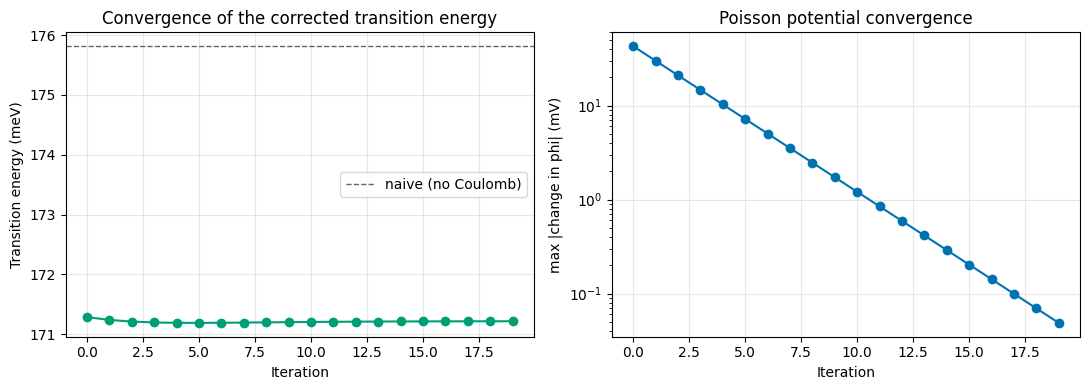

In [4]:
hist = result['history']
iters = [r['iter'] for r in hist]
transitions = [r['transition'] * 1e3 for r in hist]
changes = [r['change'] * 1e3 for r in hist]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(iters, transitions, 'o-', color="#009E73")
axes[0].axhline(result['naive_transition']*1e3, color='0.4', ls='--', lw=1, label='naive (no Coulomb)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Transition energy (meV)')
axes[0].set_title('Convergence of the corrected transition energy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, changes, 'o-', color="#0072B2")
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('max |change in phi| (mV)')
axes[1].set_title('Poisson potential convergence')
axes[1].grid(True, alpha=0.3)
fig.tight_layout()

## Band diagram: with and without the Coulomb correction

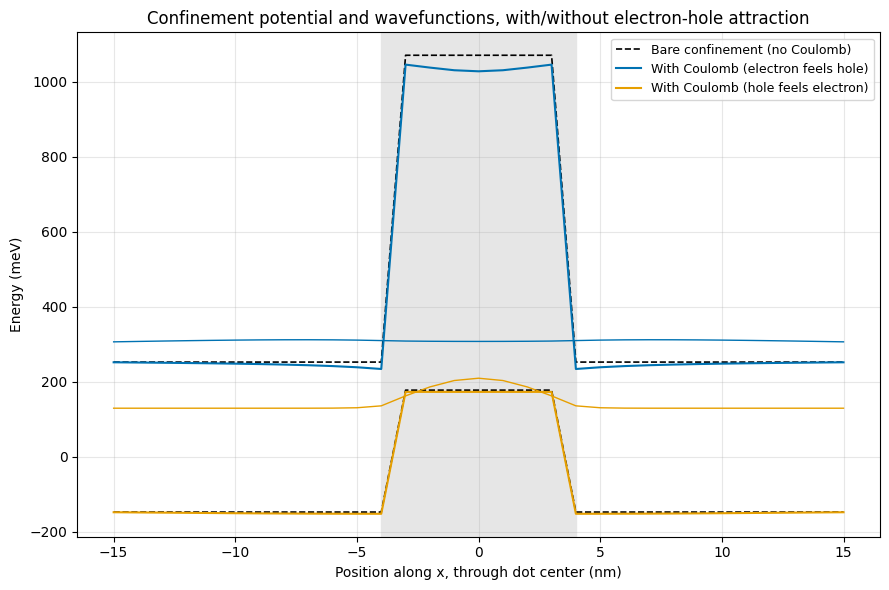

In [5]:
mid = N // 2
x_nm = coords

psi_e = result['psi_e'].reshape((N, N, N))
psi_h = result['psi_h'].reshape((N, N, N))
phi_from_n = result['phi_from_n']
phi_from_p = result['phi_from_p']

V_e_total = (V_e - phi_from_p) * 1e3
V_h_total = (V_h + phi_from_n) * 1e3

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_nm, V_e[:, mid, mid] * 1e3, color="black", lw=1.2, ls="--", label="Bare confinement (no Coulomb)")
ax.plot(x_nm, V_h[:, mid, mid] * 1e3, color="black", lw=1.2, ls="--")
ax.plot(x_nm, V_e_total[:, mid, mid], color="#0072B2", lw=1.5, label="With Coulomb (electron feels hole)")
ax.plot(x_nm, V_h_total[:, mid, mid], color="#E69F00", lw=1.5, label="With Coulomb (hole feels electron)")

scale = 0.4 * 200 / max(np.abs(psi_e[:, mid, mid]).max(), np.abs(psi_h[:, mid, mid]).max())
ax.plot(x_nm, psi_e[:, mid, mid] * scale + result['E_e'] * 1e3, color="#0072B2", lw=1.0)
ax.plot(x_nm, psi_h[:, mid, mid] * scale + result['E_h'] * 1e3, color="#E69F00", lw=1.0)

ax.axvspan(-R_dot, R_dot, color="0.9", zorder=0)
ax.set_xlabel("Position along x, through dot center (nm)")
ax.set_ylabel("Energy (meV)")
ax.set_title("Confinement potential and wavefunctions, with/without electron-hole attraction")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()